In [ ]:
!pip install fairlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Configuração visual do ambiente
sns.set_theme(style="whitegrid")
np.random.seed(42) # Semente fixada para reprodutibilidade dos alunos

# 1. Gerando 10.000 perfis de clientes
num_amostras = 10000

# Grupo Protegido A (0 = Desfavorecido, 1 = Privilegiado)
# Simulando a sociedade, a distribuição não é 50/50 em bases bancárias históricas
A = np.random.choice([0, 1], size=num_amostras, p=[0.4, 0.6])

# Inicializando matriz de features
renda_mensal = np.zeros(num_amostras)
tempo_emprego_meses = np.zeros(num_amostras)
score_credito = np.zeros(num_amostras)

# 2. Injetando o viés histórico e desigualdade de oportunidades (proxy generation)
for i in range(num_amostras):
    if A[i] == 1:
        renda_mensal[i] = np.random.normal(8500, 2000)
        tempo_emprego_meses[i] = np.random.normal(60, 20)
        score_credito[i] = np.random.normal(720, 50)
    else:
        renda_mensal[i] = np.random.normal(6000, 2000)
        tempo_emprego_meses[i] = np.random.normal(45, 20)
        score_credito[i] = np.random.normal(650, 60)

# Garantir não negatividade e formatar distribuições
renda_mensal = np.maximum(renda_mensal, 1500)
tempo_emprego_meses = np.maximum(tempo_emprego_meses, 6)

# 3. Definindo quem realmente pagaria o crédito (A Verdade / Ground Truth 'Y')
# O crédito é bom (1) se as métricas alcançam um limite estocástico
prob_sucesso = (renda_mensal / 18000) + (tempo_emprego_meses / 240) + (score_credito / 1200)
limiar_ruido = 1.3 + np.random.normal(0, 0.1, num_amostras)
Y = (prob_sucesso > limiar_ruido).astype(int)

# 4. Criando o DataFrame
df = pd.DataFrame({
    'Renda': renda_mensal,
    'Tempo_Emprego': tempo_emprego_meses,
    'Score_Credito': score_credito,
    'Atributo_Protegido': A,
    'Bom_Pagador': Y
})

In [ ]:
df.head()

,Renda,Tempo_Emprego,Score_Credito,Atributo_Protegido,Bom_Pagador
0,3024.276593,22.496278,673.329135,0,0
1,6152.253347,82.252686,716.443985,1,1
2,8671.189408,54.432541,758.642392,1,1
3,10066.319776,66.701087,748.239455,1,1
4,5575.820660,55.844060,629.727333,0,0


In [ ]:
# Omitindo propositalmente o 'Atributo_Protegido' do treinamento
X = df.drop(columns=['Atributo_Protegido', 'Bom_Pagador'])
y = df['Bom_Pagador']
atributos_sensiveis = df['Atributo_Protegido']

# Separando base de treino e teste
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, atributos_sensiveis, test_size=0.3, random_state=42
)

# Instanciando modelo padrão corporativo
modelo = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
modelo.fit(X_train, y_train)

# Predição no ambiente simulado (Test set)
y_pred = modelo.predict(X_test)
acuracia_tradicional = accuracy_score(y_test, y_pred)
print(f"Acurácia Global (A Ilusão): {acuracia_tradicional:.2%}")

Acurácia Global (A Ilusão): 85.07%


In [ ]:
df['Atributo_Protegido'].value_counts()

,count
Atributo_Protegido,
1,5942
0,4058


In [ ]:
# Importando as ferramentas métricas especializadas do fairlearn v0.13.0
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equal_opportunity_difference,
    false_positive_rate,
    false_negative_rate
)

# Definindo um dicionário de inspeção
metrics_dict = {
    'Taxa de Aprovacao (Selection)': selection_rate,
    'Taxa_Falso_Positivo (FPR)': false_positive_rate,
    'Taxa_Falso_Negativo (FNR)': false_negative_rate
}

# MetricFrame efetua o agrupamento automático
mf = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

# Imprimindo o resultado
print("\n--- Auditoria Desagregada de Viés Algorítmico ---")
print(mf.by_group)

# Calculando as métricas escalares requeridas pela EEOC e pela Legislação EU AI Act
dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
eo_diff = equal_opportunity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

print(f"\nDiferenca de Paridade Demografica: {dp_diff:.4f}")
print(f"Diferenca de Igualdade de Oportunidades: {eo_diff:.4f}")


--- Auditoria Desagregada de Viés Algorítmico ---
                    Taxa de Aprovacao (Selection)  Taxa_Falso_Positivo (FPR)  \
Atributo_Protegido                                                             
0                                        0.055369                   0.019462   
1                                        0.538717                   0.220259   

                    Taxa_Falso_Negativo (FNR)  
Atributo_Protegido                             
0                                    0.601770  
1                                    0.179353  

Diferenca de Paridade Demografica: 0.4833
Diferenca de Igualdade de Oportunidades: 0.4224


(0.0, 1.1)

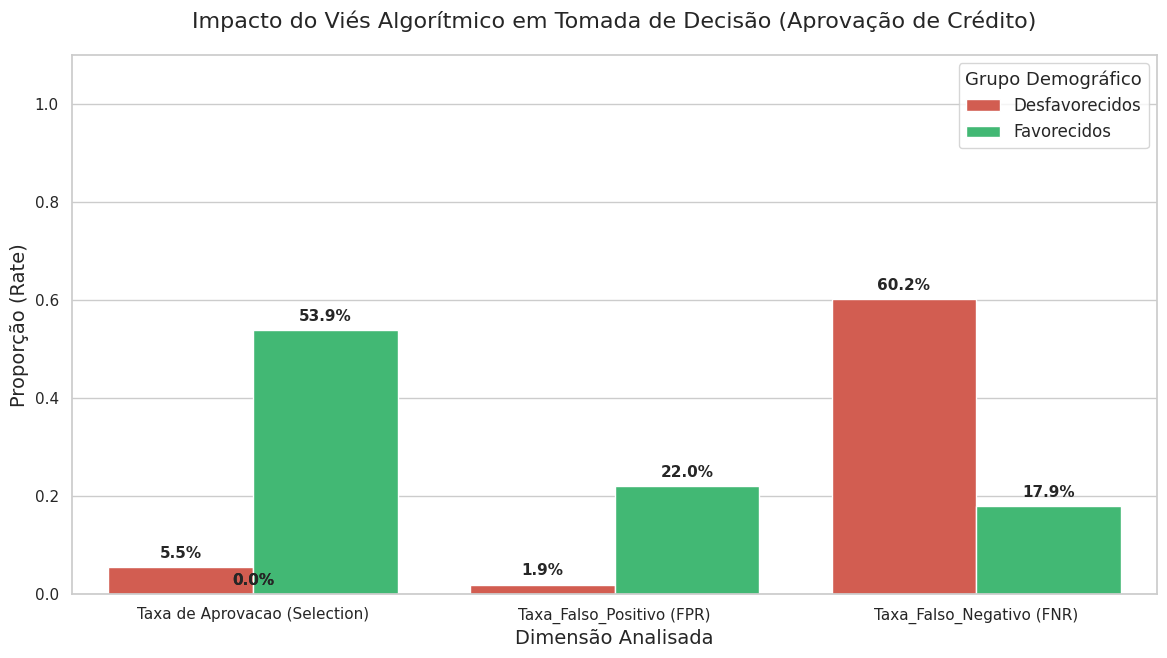

In [ ]:
# Preparando os dados desagregados para visualização amigável
tabela_metricas = mf.by_group.reset_index()

# Robustez: Renomeia a coluna do atributo sensível (geralmente a primeira) para o nome esperado.
# Isso previne erros se o Fairlearn usar um nome padrão (ex: sensitive_feature_0) ou se a celula anterior não foi rodada.
col_sensivel = tabela_metricas.columns[0]
tabela_metricas = tabela_metricas.rename(columns={col_sensivel: 'Atributo_Protegido'})

tabela_metricas['Atributo_Protegido'] = tabela_metricas['Atributo_Protegido'].map(
    {0: 'Desfavorecidos', 1: 'Favorecidos'}
)

# Identificando dinamicamente as colunas de métricas (todas exceto o atributo protegido)
metricas_cols = [c for c in tabela_metricas.columns if c != 'Atributo_Protegido']

# Função Melt do Pandas organiza o DataFrame em formato longo para o Seaborn processar eixos multivariados
df_longo = tabela_metricas.melt(
    id_vars=['Atributo_Protegido'],
    value_vars=metricas_cols,
    var_name='Métrica de Justiça (Fairness)',
    value_name='Frequência Proporcional'
)

# Plotando os Gráficos
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_longo,
    x='Métrica de Justiça (Fairness)',
    y='Frequência Proporcional',
    hue='Atributo_Protegido',
    palette=['#e74c3c', '#2ecc71'] # Vermelho de Alerta para Desfavorecidos, Verde para Favorecidos
)

# Adicionando rótulos percentuais diretos em cima das colunas
for bar in ax.patches:
    if bar.get_height() > 0 or bar.get_height() <= 0: # Check to ensure valid height
        ax.annotate(f'{bar.get_height():.1%}',
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                    ha='center', va='center', xytext=(0, 10),
                    textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Impacto do Viés Algorítmico em Tomada de Decisão (Aprovação de Crédito)', fontsize=16, pad=20)
plt.ylabel('Proporção (Rate)', fontsize=14)
plt.xlabel('Dimensão Analisada', fontsize=14)
plt.legend(title='Grupo Demográfico', fontsize=12, title_fontsize=13)
plt.ylim(0, 1.1)

# O gráfico ilustrará os picos desiguais e disparidades fatais reveladas pelo nosso algoritmo Fairlearn